In [75]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [76]:
df=pd.read_csv("loan_approval_data.csv")

In [77]:
df.head(20)

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,NaN,Car,Semiurban,Graduate,NaN,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes
5,6.0,8265.0,4831.0,Salaried,53.0,Single,1.0,602.0,1.0,0.56,19522.0,2911.0,9798.0,36.0,Home,Semiurban,Graduate,Male,Unemployed,No
6,7.0,18850.0,2768.0,Salaried,58.0,Married,0.0,687.0,0.0,0.48,14635.0,8991.0,26143.0,24.0,Home,Rural,Graduate,Male,Private,No
7,8.0,6426.0,3186.0,Salaried,47.0,Married,2.0,636.0,4.0,NaN,671.0,11572.0,33747.0,84.0,Personal,Rural,Graduate,Female,NaN,No
8,9.0,16423.0,NaN,Salaried,54.0,Married,1.0,729.0,0.0,0.59,777.0,43066.0,34651.0,36.0,Home,Semiurban,Graduate,Male,Private,No
9,10.0,13363.0,2599.0,Contract,35.0,Single,3.0,726.0,1.0,NaN,3022.0,29693.0,22182.0,60.0,Personal,Rural,Graduate,Female,Government,Yes


In [78]:
df.isnull().sum()

Applicant_ID          50
Applicant_Income      50
Coapplicant_Income    50
Employment_Status     50
Age                   50
Marital_Status        50
Dependents            50
Credit_Score          50
Existing_Loans        50
DTI_Ratio             50
Savings               50
Collateral_Value      50
Loan_Amount           50
Loan_Term             50
Loan_Purpose          50
Property_Area         50
Education_Level       50
Gender                50
Employer_Category     50
Loan_Approved         50
dtype: int64

In [79]:
categorical_cols=df.select_dtypes(include=["object"]).columns
numerical_cols=df.select_dtypes(include=["number"]).columns
print(categorical_cols)
print(numerical_cols)

Index(['Employment_Status', 'Marital_Status', 'Loan_Purpose', 'Property_Area',
       'Education_Level', 'Gender', 'Employer_Category', 'Loan_Approved'],
      dtype='object')
Index(['Applicant_ID', 'Applicant_Income', 'Coapplicant_Income', 'Age',
       'Dependents', 'Credit_Score', 'Existing_Loans', 'DTI_Ratio', 'Savings',
       'Collateral_Value', 'Loan_Amount', 'Loan_Term'],
      dtype='object')


In [80]:
for i in numerical_cols:
    df[i]=df[i].fillna(df[i].mean())
for i in categorical_cols:
    df[i]=df[i].fillna(df[i].mode()[0])
df.isnull().sum()

Applicant_ID          0
Applicant_Income      0
Coapplicant_Income    0
Employment_Status     0
Age                   0
Marital_Status        0
Dependents            0
Credit_Score          0
Existing_Loans        0
DTI_Ratio             0
Savings               0
Collateral_Value      0
Loan_Amount           0
Loan_Term             0
Loan_Purpose          0
Property_Area         0
Education_Level       0
Gender                0
Employer_Category     0
Loan_Approved         0
dtype: int64

In [81]:
df.drop(columns=["Applicant_ID"])

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.000000,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.000000,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2860.000000,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.000000,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,7390.000000,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.000000,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,13964.000000,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.000000,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,13284.000000,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.000000,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,10852.571579,9092.0,Salaried,58.0,Married,0.0,557.0,0.0,0.59,5370.000000,43563.0,8311.0,72.0,Personal,Urban,Not Graduate,Male,Unemployed,No
996,3279.000000,6356.0,Self-employed,58.0,Married,1.0,646.0,3.0,0.19,9940.452632,18361.0,22563.0,12.0,Business,Urban,Graduate,Female,Government,No
997,15192.000000,8433.0,Contract,48.0,Single,1.0,666.0,1.0,0.40,8581.000000,41335.0,16203.0,24.0,Home,Rural,Graduate,Male,MNC,No
998,9083.000000,7380.0,Unemployed,50.0,Single,1.0,748.0,3.0,0.31,13491.000000,8933.0,10290.0,36.0,Personal,Urban,Graduate,Male,Private,Yes


In [82]:
##Analyse our data

<Axes: xlabel='Applicant_Income', ylabel='Count'>

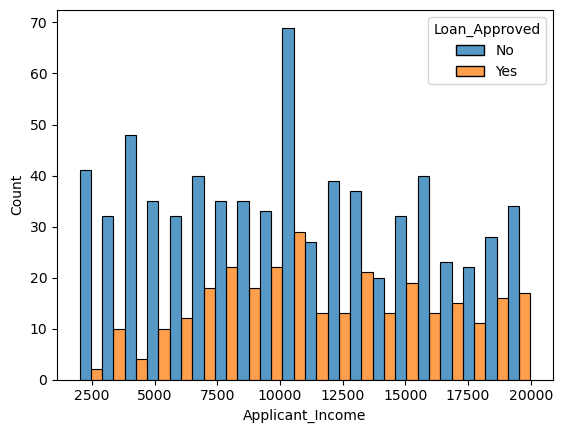

In [83]:
sns.histplot(
    data=df,
    x="Applicant_Income",
    bins=20,
    hue="Loan_Approved",
    multiple="dodge"
)

<Axes: xlabel='Credit_Score', ylabel='Count'>

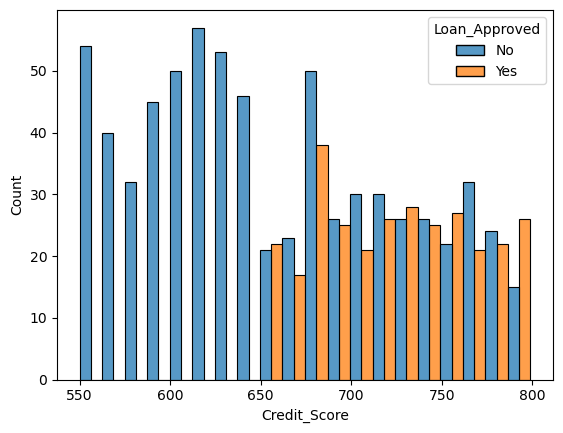

In [84]:
sns.histplot(
    data=df,
    x="Credit_Score",
    bins=20,
    hue="Loan_Approved",
    multiple="dodge"
)

<Axes: xlabel='Gender', ylabel='count'>

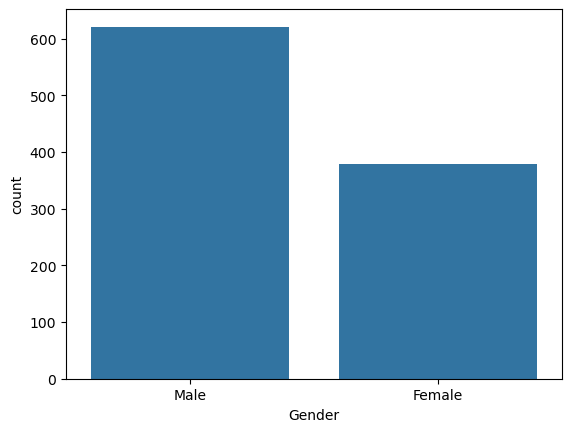

In [85]:
count_gender=df["Gender"].value_counts()
sns.barplot(count_gender)

<Axes: xlabel='Loan_Approved', ylabel='count'>

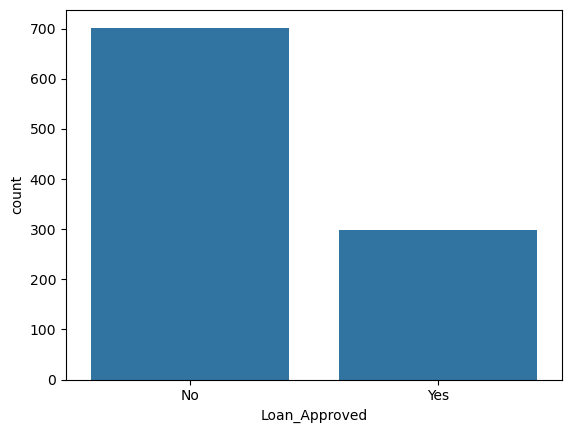

In [86]:
count_aproved=df["Loan_Approved"].value_counts()
sns.barplot(count_aproved)

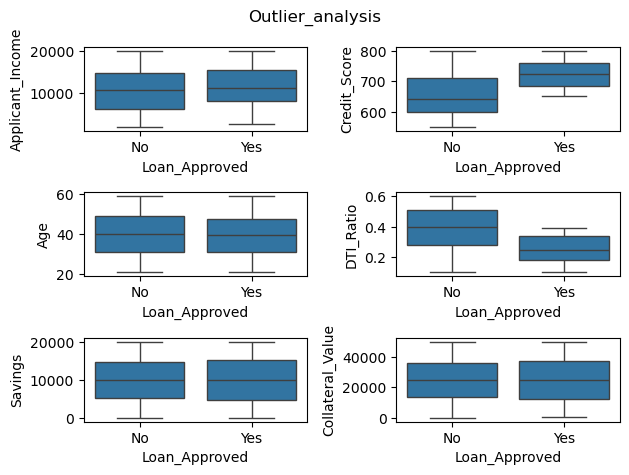

In [87]:
fig,axes=plt.subplots(3,2)
sns.boxplot(
    ax=axes[0][0],
    data=df,
    x="Loan_Approved",
    y="Applicant_Income"
)
sns.boxplot(
    ax=axes[0][1],
    data=df,
    x="Loan_Approved",
    y="Credit_Score"
)
sns.boxplot(
    ax=axes[1][0],
    data=df,
    x="Loan_Approved",
    y="Age"
)
sns.boxplot(
    ax=axes[1][1],
    data=df,
    x="Loan_Approved",
    y="DTI_Ratio"
)
sns.boxplot(
    ax=axes[2][0],
    data=df,
    x="Loan_Approved",
    y="Savings"
)
sns.boxplot(
    ax=axes[2][1],
    data=df,
    x="Loan_Approved",
    y="Collateral_Value"
)
fig.suptitle("Outlier_analysis")
fig.tight_layout()

In [88]:
empl_sts_count=df["Employment_Status"].value_counts()
print(empl_sts_count)

Employment_Status
Salaried         515
Contract         213
Self-employed    182
Unemployed        90
Name: count, dtype: int64


<Axes: xlabel='Employment_Status', ylabel='count'>

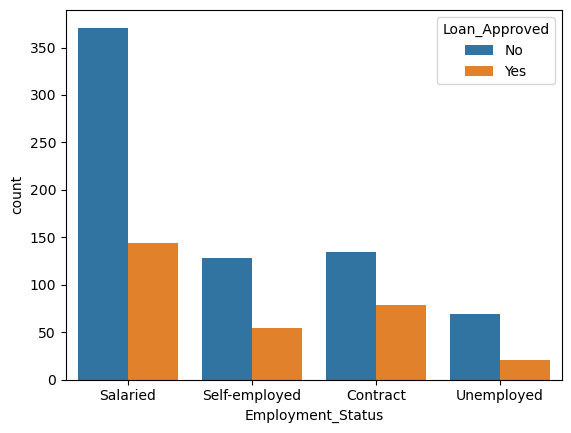

In [89]:
sns.countplot(
    data=df,
    x="Employment_Status",
    hue="Loan_Approved"
    )

In [90]:
from sklearn.preprocessing import OneHotEncoder,LabelEncoder

In [91]:
le=LabelEncoder()
df["Loan_Approved"]=le.fit_transform(df["Loan_Approved"])
df["Education_Level"]=df["Education_Level"].map({"Not Graduate":0,"Graduate":1})

In [92]:
df.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,0,Female,Private,0
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,1,Male,Private,0
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,1,Female,Government,1
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,1,Female,Government,0
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,1,Male,Private,1


In [93]:
categorical_cols=df.select_dtypes(include=["object"]).columns
categorical_cols

Index(['Employment_Status', 'Marital_Status', 'Loan_Purpose', 'Property_Area',
       'Gender', 'Employer_Category'],
      dtype='object')

In [94]:
ohe=OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore")
encoded_2D_array=ohe.fit_transform(df[categorical_cols])
encoded_df=pd.DataFrame(encoded_2D_array,columns=ohe.get_feature_names_out(categorical_cols))
updated_df=df.drop(columns=categorical_cols)
df=pd.concat([encoded_df,updated_df],axis=1)
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 29 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Employment_Status_Salaried       1000 non-null   float64
 1   Employment_Status_Self-employed  1000 non-null   float64
 2   Employment_Status_Unemployed     1000 non-null   float64
 3   Marital_Status_Single            1000 non-null   float64
 4   Loan_Purpose_Car                 1000 non-null   float64
 5   Loan_Purpose_Education           1000 non-null   float64
 6   Loan_Purpose_Home                1000 non-null   float64
 7   Loan_Purpose_Personal            1000 non-null   float64
 8   Property_Area_Semiurban          1000 non-null   float64
 9   Property_Area_Urban              1000 non-null   float64
 10  Gender_Male                      1000 non-null   float64
 11  Employer_Category_Government     1000 non-null   float64
 12  Employer_Category_MNC

In [95]:
cols=df.select_dtypes(include="number")
corr_matrix=cols.corr()
corr_matrix["Loan_Approved"].sort_values(ascending=False)

Loan_Approved                      1.000000
Credit_Score                       0.451175
Applicant_Income                   0.119796
Employer_Category_MNC              0.069049
Education_Level                    0.052920
Loan_Purpose_Personal              0.034043
Marital_Status_Single              0.030182
Property_Area_Urban                0.025963
Collateral_Value                   0.021868
Coapplicant_Income                 0.004230
Loan_Purpose_Home                  0.002118
Employment_Status_Self-employed   -0.001337
Employer_Category_Private         -0.003347
Applicant_ID                      -0.011167
Property_Area_Semiurban           -0.012967
Savings                           -0.013437
Loan_Purpose_Education            -0.016684
Employer_Category_Unemployed      -0.021468
Age                               -0.022343
Dependents                        -0.023811
Existing_Loans                    -0.034794
Employer_Category_Government      -0.039187
Employment_Status_Salaried      

<Axes: >

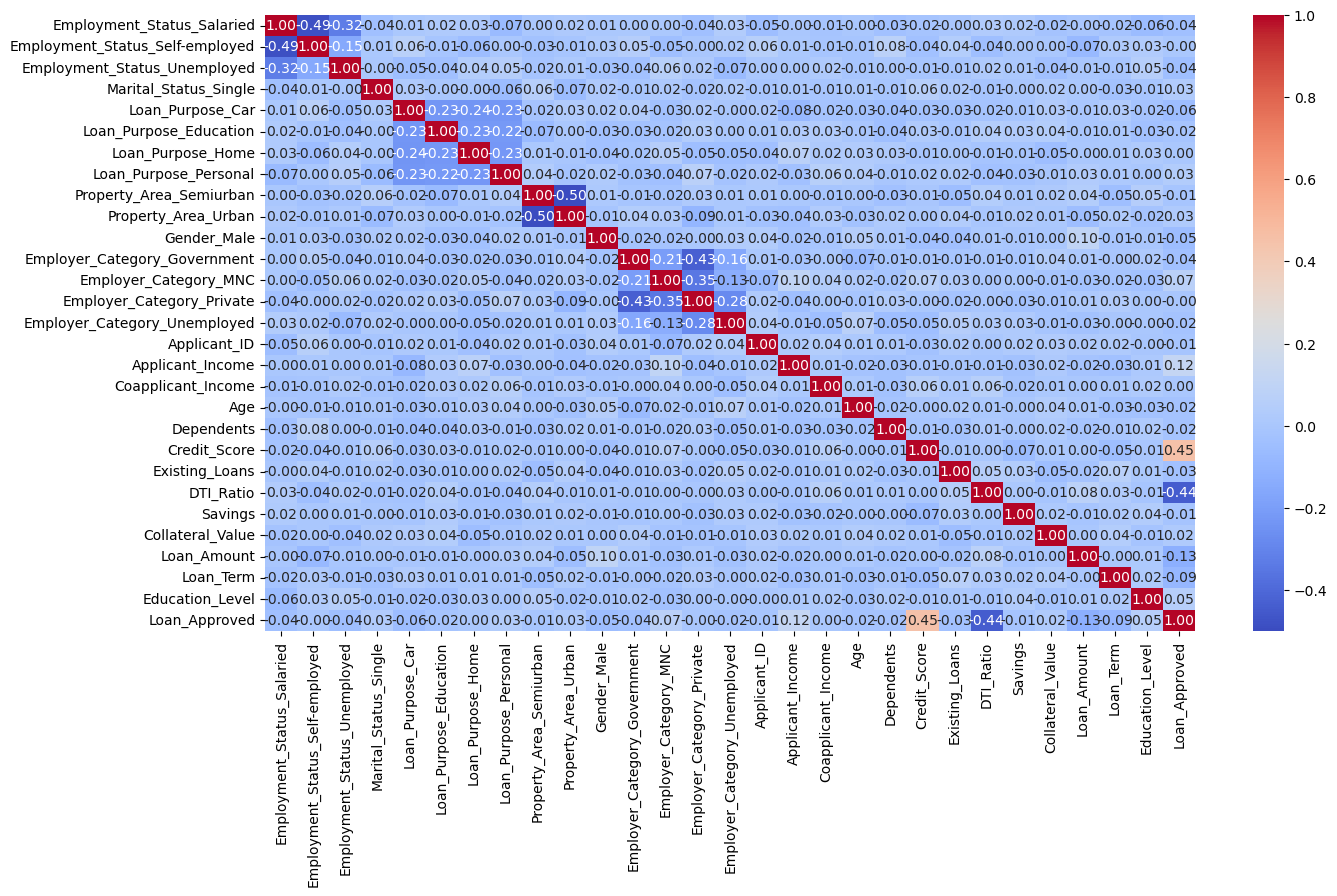

In [96]:
plt.figure(figsize=(15,8))
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    annot=True,
    fmt=".2f"
)



In [97]:
X=df.drop(columns=["Loan_Approved"])
y=df["Loan_Approved"]
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2, random_state=42)

In [98]:
from sklearn.preprocessing import StandardScaler
scaler= StandardScaler()
X_train_scaled= scaler.fit_transform(X_train)
X_test_scaled= scaler.transform(X_test)
X_train_scaled

array([[ 0.96559161, -0.48235427, -0.31207962, ...,  0.79171216,
        -1.50560555, -1.62879343],
       [ 0.96559161, -0.48235427, -0.31207962, ..., -0.50601775,
         1.02482395, -1.62879343],
       [ 0.96559161, -0.48235427, -0.31207962, ...,  0.00738475,
         0.01265215, -1.62879343],
       ...,
       [-1.03563452, -0.48235427, -0.31207962, ...,  0.51616493,
        -0.49343375, -1.62879343],
       [-1.03563452,  2.07316503, -0.31207962, ...,  0.24616623,
         1.02482395,  0.6139514 ],
       [-1.03563452, -0.48235427,  3.20431048, ..., -1.17202051,
        -1.50560555,  0.6139514 ]], shape=(800, 28))

In [99]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
lr_model= LogisticRegression()
lr_model.fit(X_train_scaled, y_train)
y_pred_lr= lr_model.predict(X_test_scaled)
print("For the LogisticRegrssion model:")
print("precision:", precision_score(y_test, y_pred_lr))
print("recall:", recall_score(y_test, y_pred_lr))
print("accuracy:", accuracy_score(y_test, y_pred_lr))
print("f1:", f1_score(y_test, y_pred_lr))

For the LogisticRegrssion model:
precision: 0.7868852459016393
recall: 0.7868852459016393
accuracy: 0.87
f1: 0.7868852459016393


In [100]:
from sklearn.naive_bayes import GaussianNB
nb_model=GaussianNB()
nb_model.fit(X_train_scaled, y_train)
y_pred_nb= nb_model.predict(X_test_scaled)
print("For the Naive Bayes model:")
print("precision:", precision_score(y_test, y_pred_nb))
print("recall:", recall_score(y_test, y_pred_nb))
print("accuracy:", accuracy_score(y_test, y_pred_nb))
print("f1", f1_score(y_test, y_pred_nb))

For the Naive Bayes model:
precision: 0.8035714285714286
recall: 0.7377049180327869
accuracy: 0.865
f1 0.7692307692307693


In [101]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
kn_classifier= KNeighborsClassifier()
param_grid= {"n_neighbors": [3,5,7,9,11]}
knn_model= GridSearchCV(
    kn_classifier,
    param_grid,
    cv=5,
    scoring="precision"
)
knn_model.fit(X_train_scaled, y_train)
y_pred_knn= knn_model.predict(X_test_scaled)
print("For the KNN model:")
print("precision:", precision_score(y_test, y_pred_knn))
print("recall:", recall_score(y_test, y_pred_knn))
print("accuracy:", accuracy_score(y_test, y_pred_knn))
print("f1:", f1_score(y_test, y_pred_knn))

For the KNN model:
precision: 0.6756756756756757
recall: 0.4098360655737705
accuracy: 0.76
f1: 0.5102040816326531


In [102]:
df["Credit_Score_sq"]=df["Credit_Score"]**2
df["DTI_Ratio_sq"]=df["DTI_Ratio"]**2
df.drop(columns=["Credit_Score","DTI_Ratio"])

,Employment_Status_Salaried,Employment_Status_Self-employed,Employment_Status_Unemployed,Marital_Status_Single,Loan_Purpose_Car,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,...,Dependents,Existing_Loans,Savings,Collateral_Value,Loan_Amount,Loan_Term,Education_Level,Loan_Approved,Credit_Score_sq,DTI_Ratio_sq
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,...,0.0,4.0,19403.000000,45638.0,16619.0,84.0,0,0,405769.0,0.2809
1,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,...,3.0,2.0,2580.000000,49272.0,38687.0,48.0,1,0,385641.0,0.0900
2,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,2.0,4.0,13844.000000,6908.0,27943.0,72.0,1,1,454276.0,0.0400
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2.0,3.0,9553.000000,10844.0,27819.0,60.0,1,0,335241.0,0.0961
4,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,...,2.0,1.0,9386.000000,37629.0,12741.0,72.0,1,1,519841.0,0.0841
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,...,0.0,0.0,5370.000000,43563.0,8311.0,72.0,0,0,310249.0,0.3481
996,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,1.0,3.0,9940.452632,18361.0,22563.0,12.0,1,0,417316.0,0.0361
997,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,1.0,8581.000000,41335.0,16203.0,24.0,1,0,443556.0,0.1600
998,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,...,1.0,3.0,13491.000000,8933.0,10290.0,36.0,1,1,559504.0,0.0961


In [103]:
X=df.drop(columns=["Loan_Approved"])
y=df["Loan_Approved"]
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2, random_state=42)

In [104]:
scaler= StandardScaler()
X_train_scaled= scaler.fit_transform(X_train)
X_test_scaled= scaler.transform(X_test)
X_train_scaled

array([[ 0.96559161, -0.48235427, -0.31207962, ..., -1.62879343,
        -1.02979529, -1.29156426],
       [ 0.96559161, -0.48235427, -0.31207962, ..., -1.62879343,
        -0.88622462, -0.97050198],
       [ 0.96559161, -0.48235427, -0.31207962, ..., -1.62879343,
        -1.27166794, -0.92735924],
       ...,
       [-1.03563452, -0.48235427, -0.31207962, ..., -1.62879343,
         0.3708418 , -0.20304575],
       [-1.03563452,  2.07316503, -0.31207962, ...,  0.6139514 ,
        -0.85984202, -0.38556665],
       [-1.03563452, -0.48235427,  3.20431048, ...,  0.6139514 ,
        -0.61853778, -0.18389941]], shape=(800, 30))

In [105]:
lr_model= LogisticRegression()
lr_model.fit(X_train_scaled, y_train)
y_pred_lr= lr_model.predict(X_test_scaled)
print("For the LogisticRegrssion model:")
print("precision:", precision_score(y_test, y_pred_lr))
print("recall:", recall_score(y_test, y_pred_lr))
print("accuracy:", accuracy_score(y_test, y_pred_lr))
print("f1:", f1_score(y_test, y_pred_lr))

For the LogisticRegrssion model:
precision: 0.765625
recall: 0.8032786885245902
accuracy: 0.865
f1: 0.784


In [106]:
nb_model=GaussianNB()
nb_model.fit(X_train_scaled, y_train)
y_pred_nb= nb_model.predict(X_test_scaled)
print("For the Naive Bayes model:")
print("precision:", precision_score(y_test, y_pred_nb))
print("recall:", recall_score(y_test, y_pred_nb))
print("accuracy:", accuracy_score(y_test, y_pred_nb))
print("f1", f1_score(y_test, y_pred_nb))

For the Naive Bayes model:
precision: 0.7910447761194029
recall: 0.8688524590163934
accuracy: 0.89
f1 0.828125


In [107]:
kn_classifier= KNeighborsClassifier()
param_grid= {"n_neighbors": [3,5,7,9,11]}
knn_model= GridSearchCV(
    kn_classifier,
    param_grid,
    cv=5,
    scoring="precision"
)
knn_model.fit(X_train_scaled, y_train)
y_pred_knn= knn_model.predict(X_test_scaled)
print("For the KNN model:")
print("precision:", precision_score(y_test, y_pred_knn))
print("recall:", recall_score(y_test, y_pred_knn))
print("accuracy:", accuracy_score(y_test, y_pred_knn))
print("f1:", f1_score(y_test, y_pred_knn))

For the KNN model:
precision: 0.7692307692307693
recall: 0.6557377049180327
accuracy: 0.835
f1: 0.7079646017699115
